## PyTorch Workflow
Let's explore an example PyTorch end-to-end workflow

In [1]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to the data (training)",
                      4: "making predictions and evaluating a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to the data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cpu'

##1. Data (preparing and loading)

Data can be almost anything.. in machine learning
* Excel spreadsheet
* Images of any kind
* Videos (YouTube has lots of data...)
* Audio like songs or podcasts
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

Let's create some *known* data using the linear regression formula.

We'll use a linear regression formula to make a straight line with *known* **parameters**.


In [3]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

Let's create a training and test set

In [5]:
# Create train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

In [6]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions
  """
  plt.figure(figsize=(10,7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # Are there predictions?
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

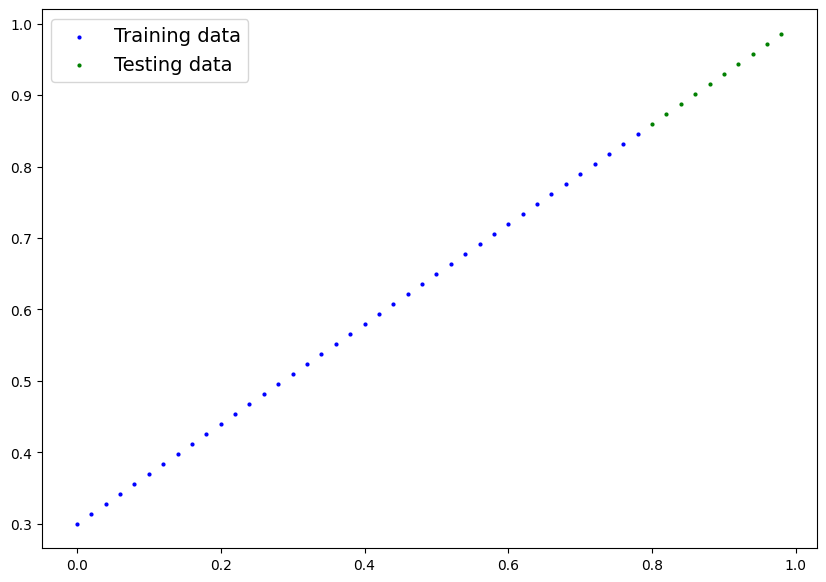

In [7]:
plot_predictions()

## 2. Build model

What our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias we used to create the data).

How does it do so?
Through two main algorithms:
1. Gradient descent
2. Backpropogation


In [8]:
# Create a linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in PyTorch inherits from nn.Module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, # <- Start with a random weight and try to adjust it to the ideal weight
                                            requires_grad=True,
                                            dtype = torch.float))
    self.bias = nn.Parameter(torch.randn(1,    # <- Start with a random weight and try to adjust it to the ideal weight
                                         requires_grad=True,
                                         dtype=torch.float))

  # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor: # "x" is the input data
    return self.weights * x + self.bias # This is the linear regression formula

## PyTorch model building essentials

* torch.nn - contains all of the buildings for computaional graphs (a nueral network can be considered a computational graph)
* torch.nn.Parameter - What parameters should our model try and leanr, often a PyTorch layer from torch. nn will set these for us
* torch.nn.Module - The base class for all nueral network modules, if you sublcass it, you should overwrite forward()
* torch.optim - This is where the optimizers in PyTorch live they will help with gradient descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

## Checking the contents of our PyTorch model

Let's see what's inside our model using `.parameters()`

In [9]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a sublass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
# List name parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test`based on `X_test`.config

When we pass data through our model, it's going to run it through the `forward()` method

In [11]:
# Make predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)

# You can also do something similar with torch.no_grad(), however, torch.inference_mode() is preferred
# with torch.no_grad():
#   y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

See more on inference mode here: https://x.com/PyTorch/status/1437838236529868803

In [12]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

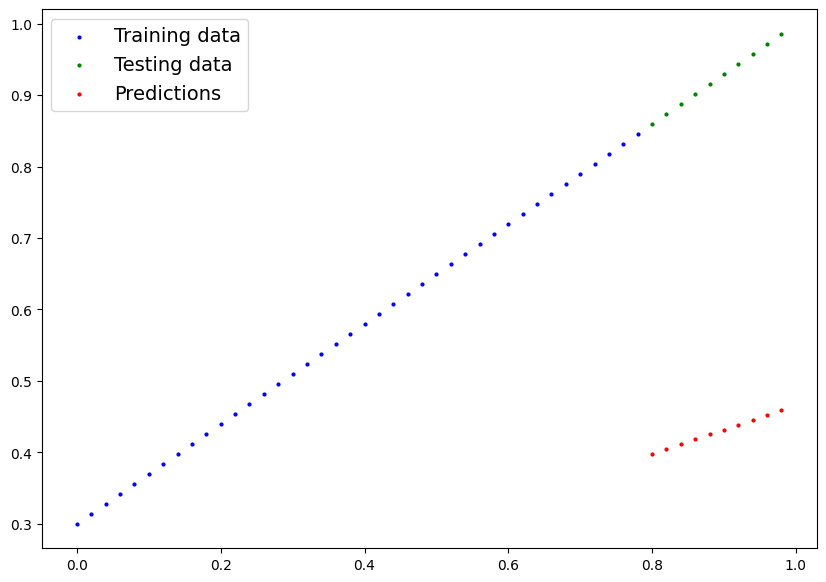

In [13]:
plot_predictions(predictions=y_preds)

# Train model

The whole idea of training is for a model to to move from some *unkown* parameters (these may be random) to some *known* parameters.

Or in other words, from a poor reprsentation of the data to a better representation of the data.

One way to measure how poor or how wrong your models predictions are is to use a loss function

* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function

Things we need to train:

**Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs. Lower is better.

**Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias in our case) to improve the loss function.
  * Inside the the optimizer you'll often have to set two parameters:
    * `params` - the model parameters you'd like to optimize, for example `params=model_0.parameters()`
    * `lr` (learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parametes with each step (a small `lr` results in small changes, a large `lr` results in large changes)

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [14]:
# Set up a loss function - Measures how wrong our model is
loss_fn = nn.L1Loss()

# Set up an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)  # ls = learning rate. Possibly the most important hyperparameter you can set

**Q:** Which loss function and optimier should I use?

**A:** This will be problem specific. But with experience, you'll' get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem (like ours), a loss function of nn.L1Loss() and an optimizer like torch.optim.SGD() will suffice.sum

But for a classification problem like classifying whtehr a photo is of a dog or a cat, you'll likely want to use a loss function of nn.BCELoss() (binary cross entropy loss)

## Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop through the data
1. Forward pass (this involves data moving through our model's forward functions) to make predictions on data - Also called forward propogation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - Move backwards through the network to calculate the gradients of each of the parametere of our model with respect to the loss (**backpropogation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [15]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [225]:
torch.manual_seed(42)

# An epoch is one loop through the data... (this is a hyperparameter because we've set it ourselves)
epochs = 20

## Training
# 0. Loop through the data
for epoch in range(epochs):
  # Set the model to training mode (this is the default state of a model)
  model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients

  #1. Forward pass on train data using the forward() method inside our model object
  y_pred = model_0(X_train)

  #2. Calculate the loss (how different are the model's predictions to the true values)
  loss = loss_fn(y_pred, y_train) # Predictions first, target second
  print(f"Loss: {loss}")

  #3. Optimizer zero grad (Zero the gradients of the optimize they accumulate by default)
  optimizer.zero_grad()

  #4. Perform backpropogation on the loss with respect to the parameters of the model
  loss.backward() # by default how the optimizer changes will accumulate through the loop so we have to zero them above in step 3 for the next iteration of the loop

  #5. Step the optimizer (perform gradient descent)
  optimizer.step()

  ## Testing
  model_0.eval()

  ## Print out model state_dict()
  print(model_0.state_dict())

Loss: 0.0025885067880153656
OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})
Loss: 0.008932482451200485
OrderedDict({'weights': tensor([0.6951]), 'bias': tensor([0.2993])})
Loss: 0.0025885067880153656
OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})
Loss: 0.008932482451200485
OrderedDict({'weights': tensor([0.6951]), 'bias': tensor([0.2993])})
Loss: 0.0025885067880153656
OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})
Loss: 0.008932482451200485
OrderedDict({'weights': tensor([0.6951]), 'bias': tensor([0.2993])})
Loss: 0.0025885067880153656
OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})
Loss: 0.008932482451200485
OrderedDict({'weights': tensor([0.6951]), 'bias': tensor([0.2993])})
Loss: 0.0025885067880153656
OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})
Loss: 0.008932482451200485
OrderedDict({'weights': tensor([0.6951]), 'bias': tensor([0.2993])})
Loss: 0.0025885067880153656
Ordered

In [226]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [227]:
with torch.inference_mode():
  y_pred_new = model_0(X_test)

In [228]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [229]:
weight, bias

(0.7, 0.3)

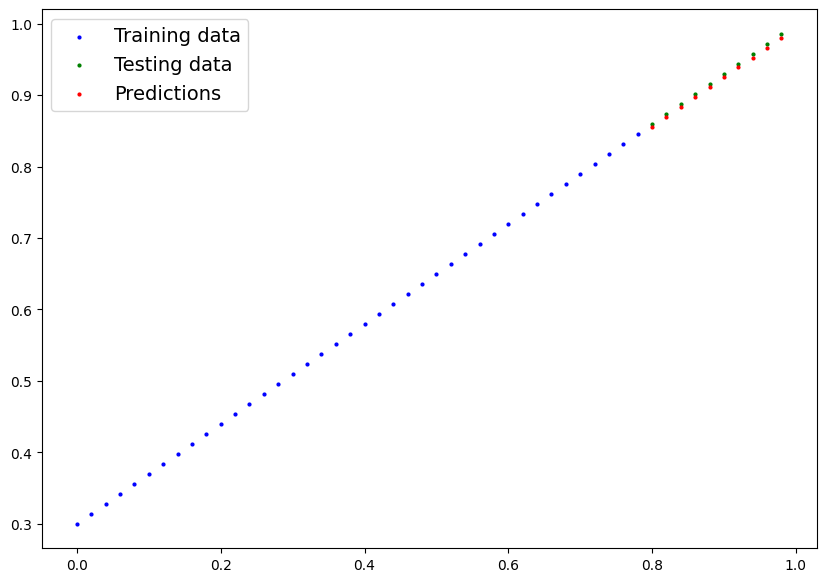

In [230]:
plot_predictions(predictions=y_pred_new)